

# Uczenie Maszynowe
czyli jak to sformułował Arthur Samuel:

***"Field of study that gives computers the ability to learn without being explicitly programmed"***

a po polsku:

"Dziedzina nauki która nadaje komputerom zdolność uczenia się bez bycia bezpośrednio zaprogramowanymi"

Zasadniczo podzielić je możemy na kilka głównych paradygmatów:

*   **Uczenie nadzorowane** (Supervised learning) - W tym przypadku mamy do czynienia z ustrukturyzowanymi danymi (posiadają etykiety, labelki) a zadaniem komputera jest przewidywanie chcianej wartości zwanej **zmienną predykcyjną**. Model "uczy się" pod nadzorem ustrukturyzowanych par (dane wejściowe, oczekiwany wynik).
*   **Uczenie nienadzorowane** (Unsupervised learning) - Przeciwieństwo powyższego. Dane wejściowe nie posiadają żadnych etykiet. Celem modelu jest samodzielne znalezienie ukrytych struktur, wzorców, czy też naturalnych grupowań (np. klasteryzacja) w zestawie danych.
* **Uczenie pół-nadzorowane** (Semi-supervised learning) - Jak łatwo zgadnąć, coś pomiędzy. Algorytm wykorzystuje niewielką ilość ustrukturyzowanych danych (z etykietami) w połączeniu z olbrzymią ilością danych nieustrukturyzowanych (bez etykiet). Często model najpierw uczy się pewnych cech z całego potężnego zbioru nieoznaczonego, a następnie na bazie niewielu etykiet precyzuje swoją wiedzę. Jest to użyteczne w praktyce, np. w analityce medycznej, gdzie pozyskanie danych z etykietami (czyli czas eksperta diagnozy) jest obrzydliwie drogie.
* **Uczenie przez wzmacnianie** (Reinforcement learning) - Diametralnie inne podejście. Tutaj algorytm (agent) wchodzi w interakcje z danym 'środowiskiem' i optymalizuje swoje zachowanie ucząc się na podstawie sygnałów wejściowych - zdefiniowanych nagród i kar w zamian za podjęte działania. Idealnie sprawdza się w przypadku treningu AI do gier, robotyki i np aut autonomicznych.

Dziś zajmiemy się

## Regresją (regression).
Ma ona na celu modelowanie zależności między zmienną celową (target value), a jedną lub więcej niezależnymi zmiennymi, zwanymi predyktorami (predictor). W przypadku Regresji **target value jest zmienną ciągłą, rzeczywistą a nie klasą.**

Zacznijmy od podstaw, czyli Regresji Liniowej (Linear Regression)



In [159]:
import numpy as np
np.random.seed(42)
import matplotlib.pyplot as plt



Mamy sobie jakieś dane, i chcielibyśmy do nich dopasować linię, tak żeby jak najlepiej je przewidywała, posłuży nam do tego najprostszy algorytm uczenia maszynowego czyli:
## Regresja liniowa

Naszym celem jest dopasowanie najprostszej w świecie linii opisywanej znanym wszystkim licealistom wzoru:

<center>
$y = ax + b$
</center>

chociaż w przypadku ML zmienną przewidywaną oznacza się za pomoca $\hat{y}$ a samo równanie często zaczyna się od wyrazu wolnego a współczynniki oznacza się za pomocą $β$ co daje:

<center>
$\hat{y} = \beta_{0} + \beta_{1}x$
</center>






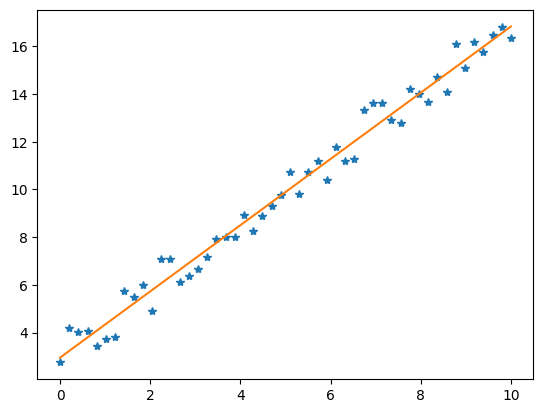

In [140]:
from sklearn.linear_model import LinearRegression

X = np.linspace(0, 10, 50)
y = (2 + 1.4*X) + np.random.rand(len(X)) * 2
plt.plot(X, y, '*')

model = LinearRegression(fit_intercept = True)

model.fit(X[:, np.newaxis], y)

x_test = np.linspace(0, 10, 20)
y_pred = model.predict(x_test[:, np.newaxis])

plt.plot(x_test, y_pred)

Sprawdźmy teraz wyraz wolny i współczynnik(i)

In [141]:
print('Wsółczynnik:  ', model.coef_[0])
print('Wyraz wolny (Intercept):', model.intercept_)

Wsółczynnik:   1.3881084873427119
Wyraz wolny (Intercept): 2.951305372070963




## Magia, działa ! 🙉

W przypadku, regresji liniowej (jak i wielomianowej) zależy nam na poprawnym przewidywaniu **współczynników**, ponieważ to one obrazują relacje między naszymi zmiennymi, więc nasz model przewidział ją bardzo dobrze, jego 1.38 do naszego 1.4.

Teraz zobaczmy krop po kroku jak to sie stało że zadziałało.

Na początek zmniejszy może troszkę ilość punktów, łatwiej będzie mi rysować 😜




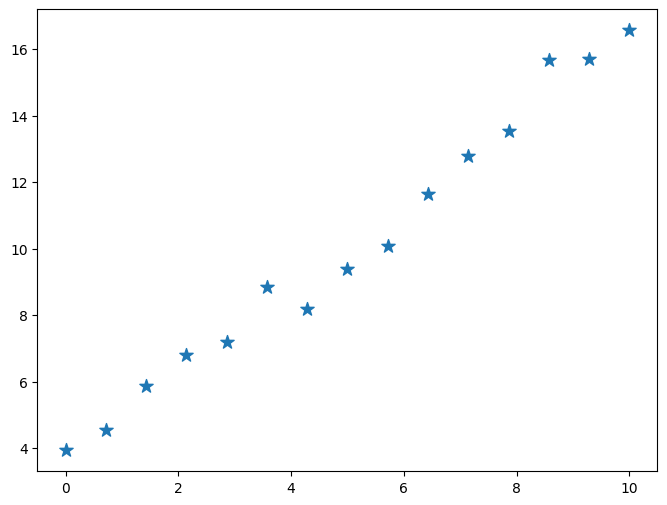

In [142]:
X = np.linspace(0, 10, 15)
y = (2 + 1.4*X) + np.random.rand(len(X)) * 2
plt.figure(figsize = (8, 6))
plt.scatter(X, y, s = 100, marker = '*')



Skoro celem regresji liniowej jest jak najlepsze dopasowanie linii do naszych danych, musi być jakiś sposób ocenienia jak dobra jest nasza przewidywana Linia.

Użyjemy do tego **RSS** czyli Residual Sum of Squares, dana wzorem:

<center>
$\text{RSS} = \sum_{i=1}^N (y_i - \hat{y}_i)^2$
</center>
gdzie:
$N$ to liczba punktów

*   $N$ = liczba punktów
*   $y_{i}$ - prawdziwa wartość danego punktu
*   $\hat{y_{i}}$ - przewidywana wartość

Ale co to są te reszty (residuals)/reszty?

Załóżmy że próbujemy dopasować do naszych punktów po prostu ich średnią





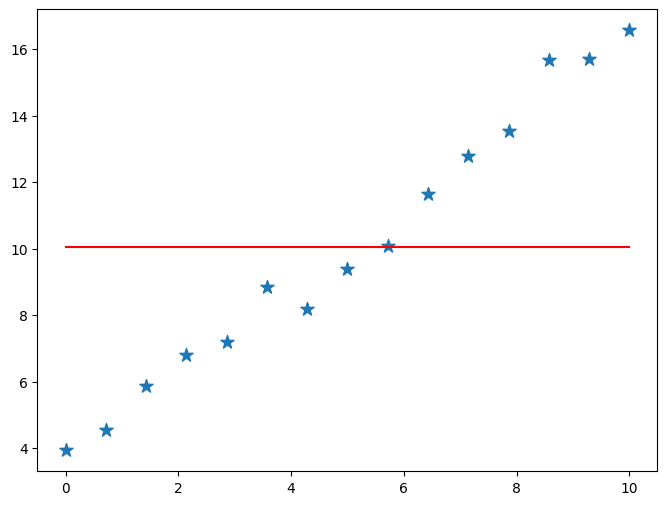

In [143]:
plt.figure(figsize = (8, 6))
plt.scatter(X, y, s = 100, marker = '*')
plt.plot(X, np.ones_like(X) * y.mean(), 'r')

**Reszty** (Residuals) to będzie różnica między prawdziwymi wartościami a wartościami przewidywanymi, czyli można to zwizualizować jako:

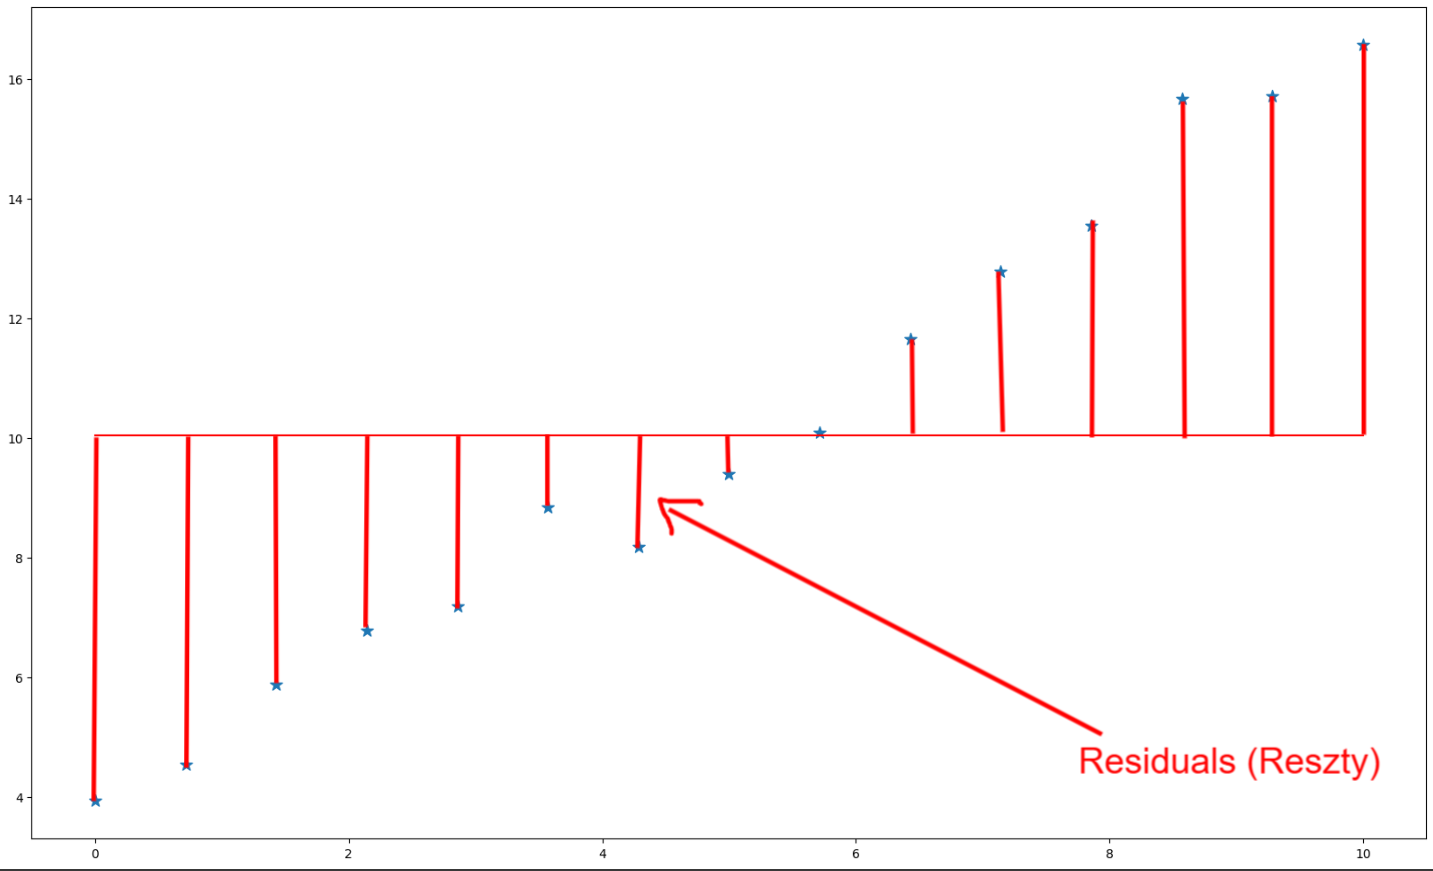



Nasz algorytm sumuje ich kwadraty (dla ułatwienia obliczeń 😉), im ich suma większa tym nasz model, nasza lina jest gorsza, więc naszym celem jest **minimalizacja** tej funkcji, czyli jest to nasza **funkcja kosztu**.

Należy również zauważyć że to co ja tutaj narysowałem tak naprawdę obrazuje nam **TSS**, czyli total sum of squares, dane wzorem:

<center>
$\text{TSS} = \sum_{i=1}^N (y_i - \bar{y})^2$
</center>
gdzie:


*   $\bar{y}$ = średnia wartości punktów

Za pomocą tych dwóch wartości, możemy obliczyć wartość $R^2$ (Coefficient of Determination), który mówi nam jaki % wariancji w naszej **zmiennej zależnej $y$** jest wyjaśniany przez nasz model, naszą linię. Im więcej tym lepiej.
$R^2$ dane jest wzorem:

<center>
$R^2 = 1 - \frac{\text{RSS}}{\text{TSS}}$
</center>

Wracając do funkcji kosztu, w celu jej optymalizacji wykorzystywany jest algorytm **Ordinary Least Squares**, który szacuje współczynniki naszej regresji rozwiązując równanie dane wzorem:

<center>
$\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}
$
</center>

gdzie $X$ reprezentuje 'design matrix', czyli macierz o wymiarach:

<center>
($n_{x} x p+1$)
</center>

gdzie:

*   $n_{x}$ - ilość obserwacji w naszym zbiorze danych
*   $p+1$ - ilość zmiennych niezależnych w zbiorze, + 1 kolumna na bias

każdy rząd odpowiada 1 punktowi a kolumna zmiennej (parametrowi)

przykładowa macierz:

|$x_{0}$ | $x_{1}$ |
|----------------|---------|
| 1              | $x_{1}$ |
| 1              | $x_{1}'$ |
| 1              | $x_{1}''$ |


Załóżmy teraz to wszystko w jedno i wprowadźmy pojęcie zbiorów **treningowego** oraz **testowego**.

# Zbiory treningowe i testowe

Są to losowo wybrane części naszego zbioru danych na podstawie których będziemy trenowali, czyli uczyli nasz model (**zbiór treningowy**) oraz testowali go jak dobrze sobie radzi na wcześniej nie spotykanych danych (**zbiór testowy**). Istnieje jeszcze **zbiór walidacyjny** który działa analogicznie do testowego, lecz jest on wykorzystywany **podczas** treningu, ale nimi będziemy się bawić kiedy indziej. Przyjęło się że zazwyczaj 80% danych zostaje przeznaczone na zbiór treningowy, a pozostałe 20% na testowy lub testowy & walidacyjny (po 10% każdy)

Do podzielenia zbioru użyjemy funkcji **train_test_split**, do której podajemy nasz X, czyli cechy (zmienne niezależne) za pomocą których chcemy przewidywać naszą zmienną, y czyli zmienną przewidywaną (zależną), rozmiar zbioru testowego, oraz random state który zapewnia powtarzalność wyników.

In [144]:
from sklearn.model_selection import train_test_split

X = np.linspace(0, 10, 500)
y = (2 + 1.4*X) + np.random.rand(len(X)) * 2
X = X.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Oceńmy teraz nasz model za pomocą standardowych statystyk, czyli

$R^2$ danego wzorem:

<center>
$R^2 = 1 - \frac{\text{RSS}}{\text{TSS}}$
</center>

jest to tak zwany **Coefficient of Determination** (Współczynnik determinacji) mówiący jak dobrze nasz model wyjaśnia zmienność w naszych danych. Czyli gdyby jego wynik wyniusł 80 oznaczało by to że relacja między zmienną x a y wyjaśnia 80% zmienności naszych danych.

Drugą metryką będzie **RMSE** czyli Root Mean Squared Error
<center>
$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}$
</center>

In [145]:
from sklearn.metrics import mean_squared_error, r2_score

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f'Wynik R^2 dla zbioru treningowego: {train_r2:.4f}')
print(f'Wynik R^2 dla zbioru testowego: {test_r2:.4f}')
print(f'Wynik RMSE dla zbioru treningowego: {train_rmse:.4f}')
print(f'Wynik RMSE dla zbioru testowego: {test_rmse:.4f}')

Wynik R^2 dla zbioru treningowego: 0.9779
Wynik R^2 dla zbioru testowego: 0.9829
Wynik RMSE dla zbioru treningowego: 0.5981
Wynik RMSE dla zbioru testowego: 0.5907


I jakiś szybki wykresik

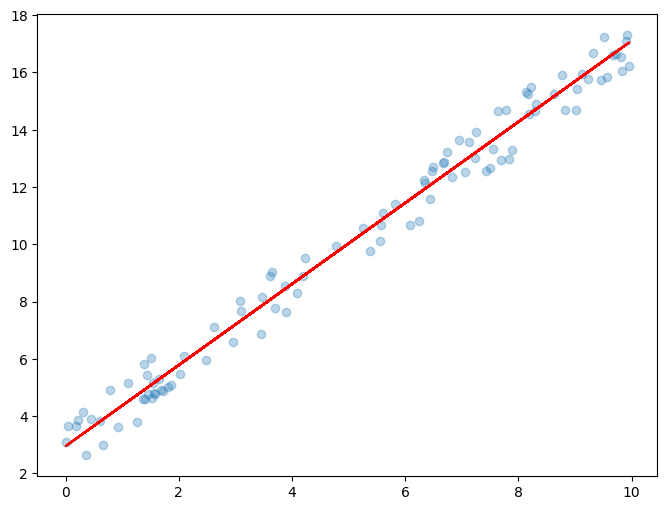

In [146]:
plt.figure(figsize = (8, 6))
plt.scatter(X_test, y_test, alpha = .3)
plt.plot(X_test, y_test_pred, color = 'r')

W ramach ciekawostki, za pomocą SGDRegressor, można w fajny sposób zobrazować działanie algorytmy Gradient Descent (Spadek wzdłóż gradientu) za pomocą którego optymalizowane są współczynniki.

W skrócie to on obraca naszą linią, stopniowo zwiększając / zmniejszając jej parametry aby jak najlepiej dopasować się do naszych danych, aby wartość jej funkcji kosztu (tym razem RSS) była najmniejsza. 😮

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning:

Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning:

Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning:

Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning:

Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning:

Maximum number o

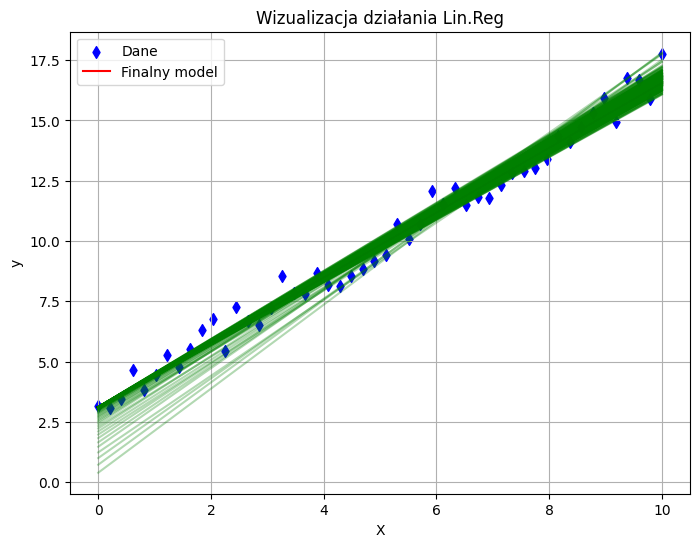

In [147]:
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor

X = np.linspace(0, 10, 50)
y = (2 + 1.4*X) + np.random.rand(len(X)) * 2
X = X.reshape(-1, 1)

# Warm start zapisuję wago po każdym wywołaniu i model zaczyna od nich przy następnym wywołaniu fit
sgd_regressor = SGDRegressor(max_iter = 1, warm_start = True, eta0 = 0.01)

beta_0_history = []
beta_1_history = []

# 20 iteracji GD
n_iterations = 20
for _ in range(n_iterations):
    sgd_regressor.fit(X, y)
    # zapisujemy parametry
    beta_0_history.append(sgd_regressor.intercept_[0])
    beta_1_history.append(sgd_regressor.coef_[0])


plt.figure(figsize = (8, 6))
plt.scatter(X, y, color = 'blue', label = 'Dane', marker = 'd')
y_final_pred = sgd_regressor.predict(X)
plt.plot(X, y_final_pred, color = 'red', label = 'Finalny model')

for i in range(0, n_iterations, 2): # Rysujemy co drugą iterację
    y_pred_i = beta_0_history[i] + beta_1_history[i] * X.flatten() # flatten, czyli spłaszczany naszą tablice z n x 1 do n, gdzie n to liczba próbek (z kolumny robimy tablice)
    plt.plot(X, y_pred_i, color = 'green', alpha = 0.3)

plt.xlabel('X')
plt.ylabel('y')
plt.title('Wizualizacja działania Lin.Reg')
plt.legend()
plt.grid(True)
plt.show()


Czyli już wiemy jak działa najprostsza regresja liniowa, ale co jeśli byśmy chcieli stworzyć model który byłby w stanie przewidzieć funkcje wyższego stopnia? kwadratowe? sześcienne? 🤔

# Regresja Wielomianowa (Polynomial Regression)

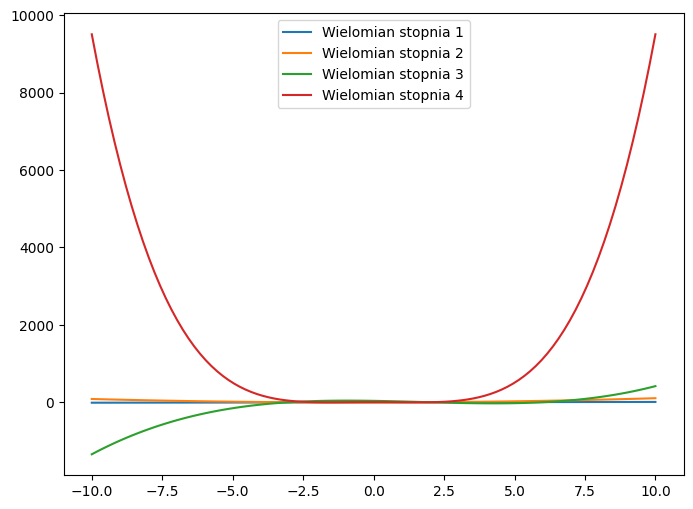

In [148]:
X = np.linspace(-10, 10, 100)
plt.figure(figsize = (8, 6))
plt.plot(X, (X - 2), label = 'Wielomian stopnia 1')
plt.plot(X, (X - 2) * (X + 3), label = 'Wielomian stopnia 2')
plt.plot(X, (X - 2) * (X + 3) * (X - 6), label = 'Wielomian stopnia 3')
plt.plot(X, (X - 2) * (X + 1) * (X + 2) * (X - 1), label = 'Wielomian stopnia 4')
plt.legend()



A no należy skorzystać z Regresji Wielomianowej (Polynomial Regression), która niestety nie jest zaimplementowana w scikit-learn, ale jest też drugi sposób, czyli cechy wielomianowe (polynomial features). W skrócie tworzone są cechy które są kolejnymi potęgami poprzednich cech, np.

Startujemy z cechą $x_{1}$, a jej wielomianowym odpowiednikiem drugiego stopnia będzie $x_1^2$, trzeciego $x_1^3$ itd.



In [149]:
from sklearn.preprocessing import PolynomialFeatures
X = np.array([[4]])
poly = PolynomialFeatures(degree = 3)
X_poly = poly.fit_transform(X)
X_poly

array([[ 1.,  4., 16., 64.]])

W przypadku gdzy mamy wiele cech dochodzi nam jeszcze:


*   Bias, czyli 1
*   Interaction term, czyli iloczen cech $x_{1}x_{2}$

Przykładowa design matrix dla regresji wielomianowej:

| $x_0$ (bias) | $x_1$ | $x_2$ | $x_1^2$ | $x_1 x_2$ | $x_2^2$ |
|--------------|-------|-------|---------|-----------|---------|
| 1            | $x_{1}$ | $x_{2}$ | $x_{1}^2$ | $x_{1} x_{2}$ | $x_{2}^2$ |
| 1            | $x_{1}'$ | $x_{2}'$ | $x_{1}'^2$ | $x_{1}' x_{2}'$ | $x_{2}'^2$ |
| 1            | $x_{1}''$ | $x_{2}''$ | $x_{1}''^2$ | $x_{1}'' x_{2}''$ | $x_{2}''^2$ |


Linia dopasowywana jest tak samo jak poprzednio, czyli za pomocą OLS


In [150]:
X = np.array([[2, 4]])
poly = PolynomialFeatures(degree = 5)
X_poly = poly.fit_transform(X)
X_poly

array([[1.000e+00, 2.000e+00, 4.000e+00, 4.000e+00, 8.000e+00, 1.600e+01,
        8.000e+00, 1.600e+01, 3.200e+01, 6.400e+01, 1.600e+01, 3.200e+01,
        6.400e+01, 1.280e+02, 2.560e+02, 3.200e+01, 6.400e+01, 1.280e+02,
        2.560e+02, 5.120e+02, 1.024e+03]])

Zobaczmy jak to działa z modelem

Mean squared error: 421.94
Coefficient of determination: 0.96


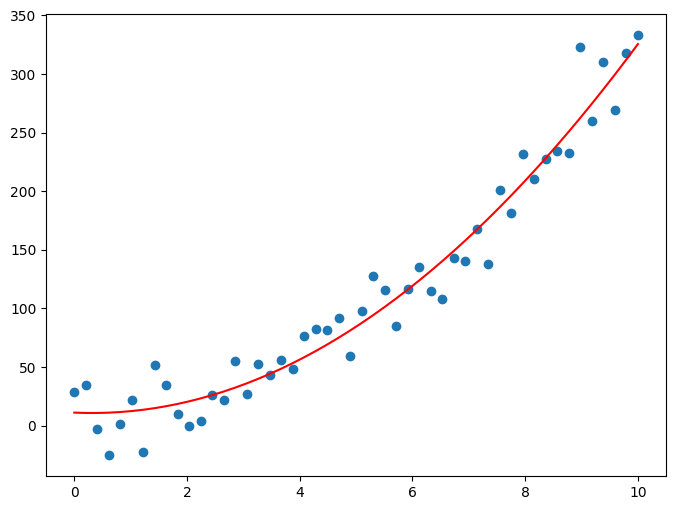

In [151]:
plt.figure(figsize = (8, 6))
X = np.linspace(0, 10, 50)
y = 1 + 2 * X + 3 * X**2 + np.random.normal(0, 25, size=X.shape)
X = X.reshape(-1, 1)

poly = PolynomialFeatures(degree = 2, include_bias = False)
X_poly = poly.fit_transform(X)
model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)

plt.scatter(X, y)
plt.plot(X, y_pred, color = 'r')

print(f'Mean squared error: {mean_squared_error(y, y_pred):.2f}')
print(f'Coefficient of determination: {r2_score(y, y_pred):.2f}')



I mamy ładną krzywą linię dopasowaną do danych. Warto jeszcze wspomnieć o Pipeline z sklearn. Umożliwi on nam stworzenie sekwencji 'transformerów' danych z klasyfikatorem na samym końcu.



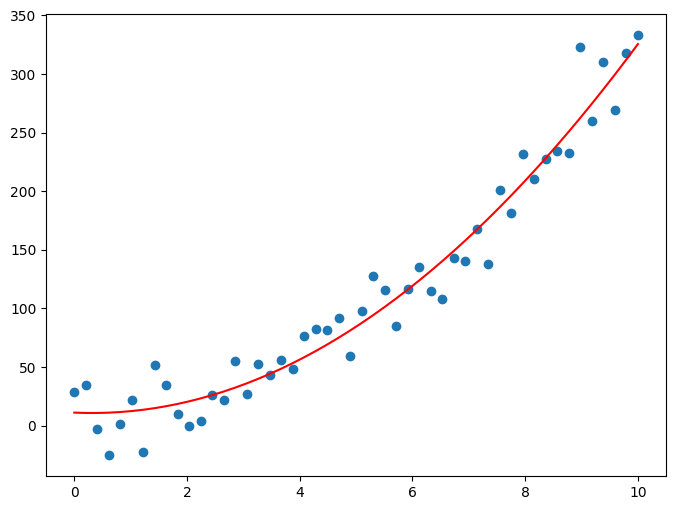

In [152]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree = 2, include_bias = False)),
    ('linreg', LinearRegression())
])

pipeline.fit(X, y)
y_pred = pipeline.predict(X)

plt.figure(figsize = (8, 6))
plt.scatter(X, y, label = 'Data')
plt.plot(X, y_pred, color = 'r')



W skrócie polynomial features to prosta i łatwa w implementacji metoda obrazowania nieliniowych zależności między $X$ a $y$. Należy jednak uważać z ilością tych cech, gdyż ich zbyt wielka ilość może prowadzić do:

1.   Overfittingu, czyli przetrenowania, nasz model dopasowuje się do każdego punktu z osobna, a nie do ogólnego trendu danych.
2.   Feature Explosion, czyli ilości cech która wpływa już na czas wykonywania naszego algorytmu


Przykład overfitting:





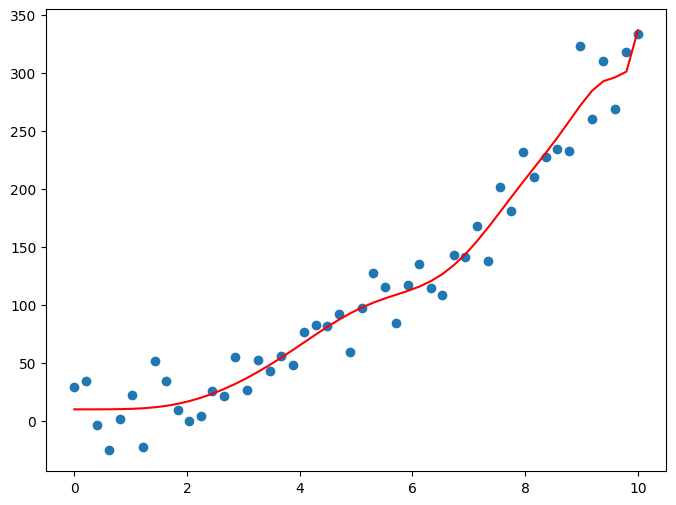

In [153]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree = 15, include_bias = False)),
    ('linreg', LinearRegression())
])

pipeline.fit(X, y)
y_pred = pipeline.predict(X)

plt.figure(figsize = (8, 6))
plt.scatter(X, y, label = 'Data')
plt.plot(X, y_pred, color = 'r')



Do tej pory zajmowaliśmy się Regresją z tylko 1 zmienną niezależną (kolumną/cechą), ale co gdy mamy ich więcej? Wtedy

# Wieloraka Regresja Liniowa / Regresja Wieloraka (Multivariate Linear Regression)

Poprzednio gdy mieliśmy do czynienia z danymi 2D nasz model przyjmował formę linii, czyli obiektu 1D, jednakże teraz będziemy bawili się danymi 3D a więc nasz model będzie przyjmował formę obiektu 2d, czyli płaszczyzny. Uogólniając model zawsze przyjmuje formę N-1 wymiarowej hiperpłaszczyzny (N-1 dimensional hyperplane) gdzie N to ilość wymiarów naszych danych.

A więc model będzie dany wzorem:

$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n + \epsilon
$

gdzie:


*  $x_p$ - wartość kolejnych cech, od $1-p$
*   $β_p$ - kolejne współczynniki cech od $1-p$
*  $β_{0}$ - bias
*   $ϵ$ - n x 1 wymiarowy wektor reszt ($n$ - ilośc punktów w zbiorze)


I również jak poprzednio do optymalizacji wykorzystywana jest design matrix i OLS

design matrix dla regresji wielorakiej:

| $x_0$ (bias) | $x_1$ | $x_2$ |
|--------------|-------|-------|
| 1            | $x_{1}$ | $x_{2}$ |
| 1            | $x_{1}'$ | $x_{2}'$ |
| 1            | $x_{1}''$ | $x_{2}''$ |





In [154]:
import plotly.graph_objects as go

# Przykładowe, sysntetyczne dane o wzroście, gęstości kości i wadze
np.random.seed(42)
height = np.random.uniform(150, 200, 100)
bone_density = np.random.uniform(0.8, 1.2, 100)
weight = (40 + 0.8 * height + 15 * bone_density + np.random.normal(0, 5, 100)) * 0.453


X = np.column_stack((height, bone_density))
y = weight

lin_reg = LinearRegression()
lin_reg.fit(X, y)

y_pred = lin_reg.predict(X)

# Oceniamy model
mse = mean_squared_error(y, y_pred)
print(f'Mean Squared Error: {mse:.2f}')

intercept = lin_reg.intercept_
coef_height, coef_bone_density = lin_reg.coef_

height_range = np.linspace(height.min(), height.max(), 50)
bone_density_range = np.linspace(bone_density.min(), bone_density.max(), 50)
H, B = np.meshgrid(height_range, bone_density_range) # https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html
W = intercept + coef_height * H + coef_bone_density * B

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=height, y=bone_density, z=weight,
    mode = 'markers',
    marker = dict(size = 5, color = 'blue', opacity = 0.8),
    name = 'Waga'
))

fig.add_trace(go.Surface(
    x = height_range,
    y = bone_density_range,
    z = W,
    colorscale = 'Viridis',
    opacity = 0.7,
    name = 'Płaszczyzna regresji'
))

fig.update_layout(
    title = 'Wizualizacja regresji wielorakiej',
    scene = dict(
        xaxis_title = 'Wzrost',
        yaxis_title = 'gęstość kości',
        zaxis_title = 'Waga'
    ),
    showlegend = True
)

fig.show()


Mean Squared Error: 4.85


# Drzewa regresyjne
Podobnie jak normalne drzewo decyzyjne, o którym porozmawiamy na nast. lekcji, drzewo regresyjne rekursywnie dzieli nasz zbiór danych za pomocą drzewa binarnego. Każda gałąź (node) drzewa to poszczególny warunek, jak np. $x_{1} > 16$. Punkty spełniające nasz warunek idą w lewo, te niespełniające idą w prawo. Każda kolejna gałąź to kolejny warunek, a zadaniem drzewa jest znaleźć jak 'najczystsze' (najlepiej dzielące nasze dane) gałęzie.
W przypadku drzewa regresyjnego, jedynymi różnicami są :

1.   Jak obliczamy 'zanieczyszczenie' (impurity) gałęzi. W przypadku Drzew Regresyjnych będzie to Wariacja dana wzorem
<center>
 $\text{Var}(X) = \sigma^2 = \frac{\sum_{i=1}^{n} (x_i - \mu)^2}{n}$
 </center>
2.   W jaki sposób dokonujemy 'decyzji'. Zamiast głosowania większościowego, bierzemy tutaj średnią wszystkich obserwacji w danym liściu. Najprościej jak się da 😺



In [155]:
from sklearn.tree import DecisionTreeRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

# Trenujemy
reg_tree = DecisionTreeRegressor(max_depth = 3)  # Maksymalna głębokośc drzewa = 3
reg_tree.fit(X_train, y_train)

# Przewidujemy
y_pred = reg_tree.predict(X_test)

# Oceniamy model
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')

Mean Squared Error: 5.11




Wizualizacja płaszczyzny regresji Drzewa regresyjnego, bardzo ładnie pokazuje poszczególne decyzje podejmowane przez te drzewo. W pewnym stopniu zaczyna nawet przypominać problem klasyfikacji 🤔



In [156]:
import plotly.express as px

fig_scatter = px.scatter_3d(
    x = X_test[:, 0],
    y = X_test[:, 1],
    z = y_test,
    labels = {'x': 'Wzrost (cm)', 'y': 'Gęstość Kości', 'z': 'Waga (kg)'},
    title = 'Oryginalne dane',
    opacity = 0.7,
    color = y_test,
    color_continuous_scale = 'Viridis'
)

height_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 50)
bone_density_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 50)
H, B = np.meshgrid(height_range, bone_density_range)
X_grid = np.c_[H.ravel(), B.ravel()]

# Przewidujemy
Z_pred = reg_tree.predict(X_grid)
Z_pred = Z_pred.reshape(H.shape)

# Dodajemy płaszczyznę regresyjną
fig_scatter.add_trace(go.Surface(x = H,
                                 y = B,
                                 z = Z_pred,
                                 colorscale = 'Plasma',
                                 opacity = 0.6,
                                 name = '"Przewidywania" drzewa regresyjnego'))

fig_scatter.update_layout(scene = dict(zaxis_title = 'Waga (kg)'))
fig_scatter.show()

In [157]:
from plotly.subplots import make_subplots

fig_boundaries = make_subplots(rows = 1, cols = 2,
                               subplot_titles = ('Wzrost a Waga', 'Gęstość Kości a Waga'))

# Sortujemy dane testowe, wykres będzie sensowniejszy
sorted_indices_height = np.argsort(X_test[:, 0])
sorted_height = X_test[sorted_indices_height, 0]
sorted_weight_pred_height = y_pred[sorted_indices_height]

sorted_indices_bone = np.argsort(X_test[:, 1])
sorted_bone = X_test[sorted_indices_bone, 1]
sorted_weight_pred_bone = y_pred[sorted_indices_bone]


fig_boundaries.add_trace(go.Scatter(x = X_test[:, 0],
                                    y = y_test,
                                    mode = 'markers',
                                    name = 'Rzeczywista waga',
                                    marker = dict(color = 'blue')),
                         row = 1, col = 1)
# Linia regresji
fig_boundaries.add_trace(go.Scatter(x = sorted_height,
                                    y = sorted_weight_pred_height,
                                    mode = 'lines',
                                    name = 'Przewidywana Waga',
                                    line = dict(color = 'red', shape = 'hv')),
                         row = 1, col = 1)

fig_boundaries.update_xaxes(title_text = 'Wzrost (cm)', row = 1, col = 1)
fig_boundaries.update_yaxes(title_text = 'Waga (kg)', row = 1, col = 1)


fig_boundaries.add_trace(go.Scatter(x = X_test[:, 1],
                                    y = y_test,
                                    mode = 'markers',
                                    name = 'Rzeczywista waga',
                                    marker = dict(color = 'blue'),
                                    showlegend = False),
                         row = 1, col = 2)
# Linia regresji nr.2
fig_boundaries.add_trace(go.Scatter(x=sorted_bone,
                                    y=sorted_weight_pred_bone, mode = 'lines',
                                    name = 'Przewidywana waga (Tree)',
                                    line = dict(color = 'red', shape = 'hv'),
                                    showlegend = False),
                         row = 1, col = 2)

fig_boundaries.update_xaxes(title_text = 'Gęstość kości', row = 1, col = 2)
fig_boundaries.update_yaxes(title_text = 'Waga (kg)', row = 1, col = 2)

fig_boundaries.update_layout(title_text = 'Rzeczywista a przewidywana waga w 2D')
fig_boundaries.show()

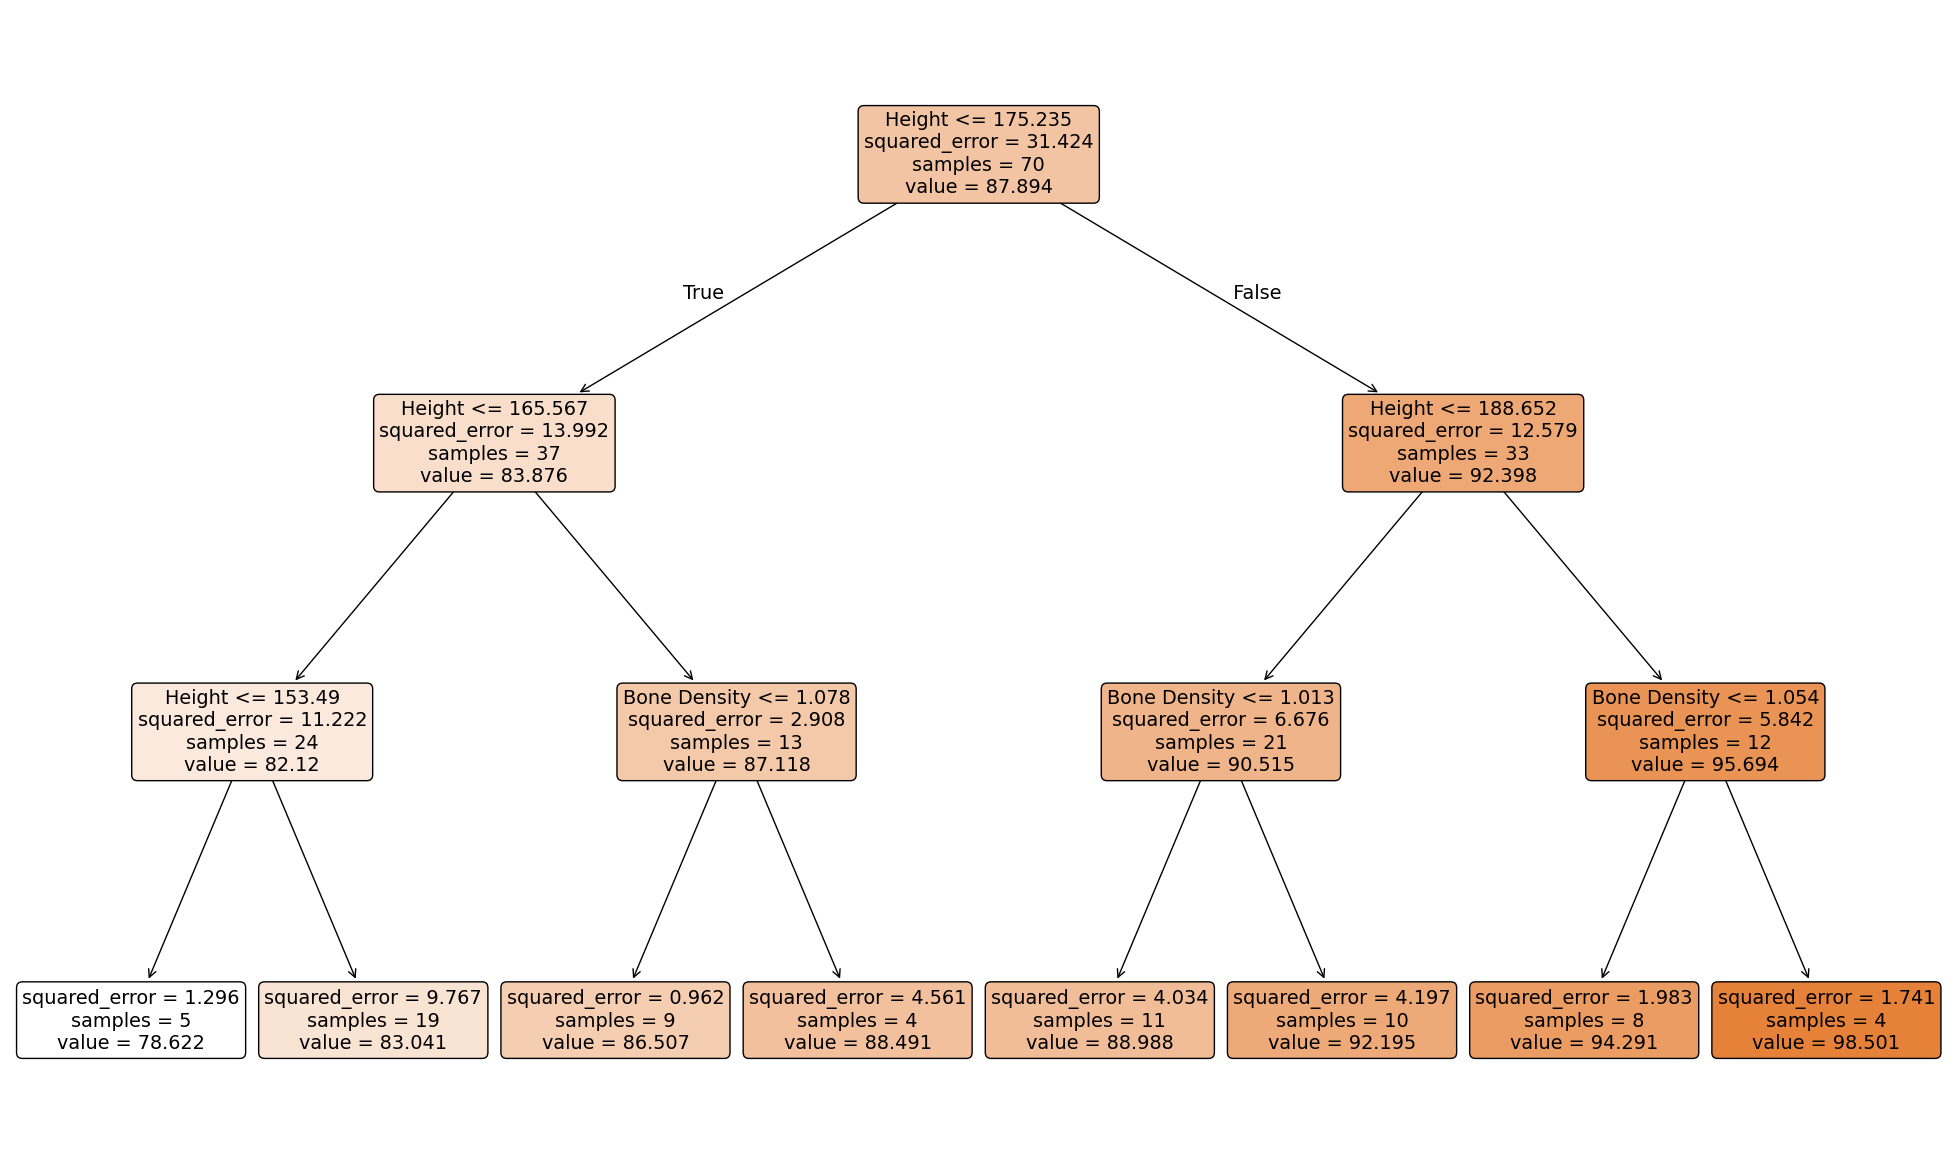

In [158]:
from sklearn.tree import plot_tree

plt.figure(figsize = (25, 15))
plot_tree(reg_tree,
          feature_names = ['Height', 'Bone Density'],
          filled = True,
          rounded = True)
plt.show()